In [ ]:
import pandas as pd
import numpy as np
import torch
import transformers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from transformers import AutoModel, BertTokenizerFast, DistilBertTokenizerFast, AutoTokenizer
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight
from tqdm.notebook import tqdm
import os
import shap
import spacy
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score
from collections import defaultdict, Counter
import random
import pickle

In [ ]:
seed_num = 42

In [ ]:
random.seed(seed_num)
np.random.seed(seed_num)
torch.manual_seed(seed_num)

In [ ]:
split_num = 1

In [ ]:
nlp = spacy.load("en_core_web_sm")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Read Data

In [ ]:
os.chdir('/content/drive/My Drive/NLP-Letters-V2/notebooks/')
df = pd.read_csv('../data/combined_letters_degendered.csv')

# Create Training and Test Sets

In [ ]:
# train_text, temp_text, train_labels, temp_labels = train_test_split(df['full_text'], df['label'], test_size=0.2, random_state=seed_num, stratify=df['label'])

# val_text, test_text, val_labels, test_labels = train_test_split(temp_text, temp_labels, test_size=0.5, random_state=seed_num, stratify=temp_labels)

In [ ]:
base_path = "../data/train_test_val_splits/distillbert/explicit_gendered_tokens_removed"


train_df = pd.read_csv(f"{base_path}/train_text_{split_num}.csv")
train_text   = train_df["full_text"]
train_labels = train_df["label"]

val_df = pd.read_csv(f"{base_path}/val_text_{split_num}.csv")
val_text   = val_df["full_text"]
val_labels = val_df["label"]

test_df = pd.read_csv(f"{base_path}/test_text_{split_num}.csv")
test_text   = test_df["full_text"]
test_labels = test_df["label"]

In [ ]:
bert = AutoModel.from_pretrained("distilbert/distilbert-base-uncased")
tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-uncased")

In [ ]:
tokens_train = tokenizer.batch_encode_plus(
    train_text.tolist(),
    padding='max_length',
    truncation=True,
    return_tensors="pt"
)

tokens_val = tokenizer.batch_encode_plus(
    val_text.tolist(),
    padding='max_length',
    truncation=True,
    return_tensors="pt"
)

tokens_test = tokenizer.batch_encode_plus(
    test_text.tolist(),
    padding='max_length',
    truncation=True,
    return_tensors="pt"
)

In [ ]:
train_seq = torch.tensor(tokens_train['input_ids'])
train_mask = torch.tensor(tokens_train['attention_mask'])
train_y = torch.tensor(train_labels.tolist())

val_seq = torch.tensor(tokens_val['input_ids'])
val_mask = torch.tensor(tokens_val['attention_mask'])
val_y = torch.tensor(val_labels.tolist())

test_seq = torch.tensor(tokens_test['input_ids'])
test_mask = torch.tensor(tokens_test['attention_mask'])
test_y = torch.tensor(test_labels.tolist())

/tmp/ipython-input-2686642901.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_seq = torch.tensor(tokens_train['input_ids'])
/tmp/ipython-input-2686642901.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_mask = torch.tensor(tokens_train['attention_mask'])
/tmp/ipython-input-2686642901.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_seq = torch.tensor(tokens_val['input_ids'])
/tmp/ipython-input-2686642901.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or 

In [ ]:
batch_size = 16
train_data = TensorDataset(train_seq, train_mask, train_y)
train_sampler = RandomSampler(train_data)
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)

val_data = TensorDataset(val_seq, val_mask, val_y)
val_sampler = SequentialSampler(val_data)
val_dataloader = DataLoader(val_data, sampler = val_sampler, batch_size=batch_size)

In [ ]:
# freeze weights, uncomment if you would like to unfreeze weights
for param in bert.parameters():
    param.requires_grad = False


In [ ]:
# Unfreeze top 2 layers to start (layers 4 and 5)
for i in [4, 5]:
    for param in bert.transformer.layer[i].parameters():
        param.requires_grad = True


# Create Model

In [ ]:
class BERT_Arch(nn.Module):

    def __init__(self, bert):

        super(BERT_Arch, self).__init__()

        self.bert = bert

        # dropout layer
        self.dropout = nn.Dropout(0.1)

        # relu activation function
        self.relu =  nn.ReLU()

        # dense layer 1
        self.fc1 = nn.Linear(bert.config.hidden_size,128)

        # dense layer 2 (Output layer)
        self.fc2 = nn.Linear(128,2)

        #softmax activation function
        self.softmax = nn.LogSoftmax(dim=1)

    #define the forward pass
    def forward(self, sent_id, mask):

        #pass the inputs to the model
        distilbert_output = self.bert(sent_id, attention_mask=mask)

        hidden_state = distilbert_output[0]  # (bs, seq_len, dim)
        pooled_output = hidden_state[:, 0]

        x = self.fc1(pooled_output)

        x = self.relu(x)

        x = self.dropout(x)

        # output layer
        x = self.fc2(x)

        # apply softmax activation
        x = self.softmax(x)

        return x

In [ ]:
model = BERT_Arch(bert)
model = model.to(device)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_labels), y=train_labels)
weights= torch.tensor(class_weights, dtype=torch.float)
weights = weights.to(device)
cross_entropy  = nn.NLLLoss(weight=weights)
epochs = 10

In [ ]:
# function to train the model
def train():

  model.train()

  total_loss, total_accuracy = 0, 0

  # empty list to save model predictions
  total_preds=[]
  total_labels=[]


  # Gradual unfreezing for layers 3 → 0 every 2 epochs starting at epoch 2
  # layers_to_unfreeze = [3, 2, 1, 0]  # already started with 5 & 4 unfrozen

  # Compute how many new layers to unfreeze so far (0 at epoch 0–1, 1 at epoch 2–3, etc.)
  # layer_unfreeze_index = (epoch - 2) // 2

  # if 0 <= layer_unfreeze_index < len(layers_to_unfreeze):
  #     layer_idx = layers_to_unfreeze[layer_unfreeze_index]
  #     for param in model.bert.transformer.layer[layer_idx].parameters():
  #         param.requires_grad = True
  #     print(f"Epoch {epoch}: Unfroze DistilBERT layer {layer_idx}")


  # iterate over batches
  for step,batch in enumerate(tqdm(train_dataloader, desc="Training", leave=True)):

    # push the batch to gpu
    batch = [r.to(device) for r in batch]

    sent_id, mask, labels = batch

    # clear previously calculated gradients
    model.zero_grad()

    # get model predictions for the current batch
    preds = model(sent_id, mask)

    # compute the loss between actual and predicted values
    loss = cross_entropy(preds, labels)

    # add on to the total loss
    total_loss = total_loss + loss.item()

    # backward pass to calculate the gradients
    loss.backward()

    # clip the the gradients to 1.0. It helps in preventing the exploding gradient problem
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

    # update parameters
    optimizer.step()

    # model predictions are stored on GPU. So, push it to CPU
    preds=preds.detach().cpu().numpy()

    # append the model predictions
    total_preds.append(preds)

    labels=labels.detach().cpu().numpy()

    # append labels
    total_labels.append(labels)

  # compute the training loss of the epoch
  avg_loss = total_loss / len(train_dataloader)

  # predictions are in the form of (no. of batches, size of batch, no. of classes).
  # reshape the predictions in form of (number of samples, no. of classes)
  total_preds  = np.concatenate(total_preds, axis=0)

  total_labels = np.concatenate(total_labels, axis=0)

  epoch_preds = np.argmax(total_preds, axis = 1)

  print('Training Classification Report: \n', classification_report(total_labels, epoch_preds))
  print('Training Confusion Matrix: \n', confusion_matrix(total_labels, epoch_preds))

  #returns the loss and predictions
  return avg_loss, total_preds

In [ ]:
# function for evaluating the model
def evaluate():

  print("\nEvaluating...")

  # deactivate dropout layers
  model.eval()

  total_loss, total_accuracy = 0, 0

  # empty list to save the model predictions
  total_preds = []
  total_labels = []

  # iterate over batches
  for step,batch in enumerate(val_dataloader):

    # push the batch to gpu
    batch = [t.to(device) for t in batch]

    sent_id, mask, labels = batch

    # deactivate autograd
    with torch.no_grad():

      # model predictions
      preds = model(sent_id, mask)

      # compute the validation loss between actual and predicted values
      loss = cross_entropy(preds,labels)

      total_loss = total_loss + loss.item()

      preds = preds.detach().cpu().numpy()

      total_preds.append(preds)

      labels = labels.detach().cpu().numpy()

      total_labels.append(labels)

  # compute the validation loss of the epoch
  avg_loss = total_loss / len(val_dataloader)

  # reshape the predictions in form of (number of samples, no. of classes)
  total_preds  = np.concatenate(total_preds, axis=0)

  total_labels = np.concatenate(total_labels, axis=0)

  epoch_preds = np.argmax(total_preds, axis = 1)

  print('Validation Classification Report: \n', classification_report(total_labels, epoch_preds))
  print('Validation Confusion Matrix: \n', confusion_matrix(total_labels, epoch_preds))

  return avg_loss, (epoch_preds, total_labels)

In [ ]:
# set initial loss to infinite
# best_valid_loss = float('inf')
best_macro_f1 = 0.0

# empty lists to store training and validation loss of each epoch
train_losses=[]
valid_losses=[]
macro_f1_scores = []

#for each epoch
for epoch in tqdm(range(epochs), desc="Training"):

    print('\n Epoch {:} / {:}'.format(epoch + 1, epochs))

    #train model
    train_loss, _ = train()

    #evaluate model
    valid_loss, (all_preds, all_labels) = evaluate()

    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    macro_f1_scores.append(macro_f1)

    # Save the best model based on F1 score
    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        print('Model Saved (best F1)!')
        torch.save(model, f'../saved_models/explicit_gender_token_removal/saved_model_distillbert_{split_num}.pt')

    # #save the best model
    # if valid_loss < best_valid_loss:
    #     best_valid_loss = valid_loss
    #     print('Model Saved!')
    #     torch.save(model, '../saved_models/saved_model.pt')

    # append training and validation loss
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    print(f'\nTraining Loss: {train_loss:.3f}')
    print(f'Validation Loss: {valid_loss:.3f}')

Training:   0%|          | 0/10 [00:00<?, ?it/s]


 Epoch 1 / 10


Training:   0%|          | 0/450 [00:00<?, ?it/s]

Training Classification Report: 
               precision    recall  f1-score   support

           0       0.32      0.35      0.34      2229
           1       0.70      0.67      0.68      4960

    accuracy                           0.57      7189
   macro avg       0.51      0.51      0.51      7189
weighted avg       0.58      0.57      0.58      7189

Training Confusion Matrix: 
 [[ 790 1439]
 [1649 3311]]

Evaluating...
Validation Classification Report: 
               precision    recall  f1-score   support

           0       0.50      0.01      0.01       278
           1       0.69      1.00      0.82       621

    accuracy                           0.69       899
   macro avg       0.60      0.50      0.42       899
weighted avg       0.63      0.69      0.57       899

Validation Confusion Matrix: 
 [[  2 276]
 [  2 619]]
Model Saved (best F1)!

Training Loss: 0.693
Validation Loss: 0.690

 Epoch 2 / 10


Training:   0%|          | 0/450 [00:00<?, ?it/s]

...

Training Classification Report: 
               precision    recall  f1-score   support

           0       0.52      0.67      0.58      2229
           1       0.83      0.72      0.77      4960

    accuracy                           0.70      7189
   macro avg       0.67      0.69      0.68      7189
weighted avg       0.73      0.70      0.71      7189

Training Confusion Matrix: 
 [[1497  732]
 [1407 3553]]

Evaluating...
Validation Classification Report: 
               precision    recall  f1-score   support

           0       0.40      0.49      0.44       278
           1       0.75      0.67      0.71       621

    accuracy                           0.62       899
   macro avg       0.58      0.58      0.58       899
weighted avg       0.64      0.62      0.63       899

Validation Confusion Matrix: 
 [[137 141]
 [203 418]]

Training Loss: 0.573
Validation Loss: 0.717

 Epoch 9 / 10


Training:   0%|          | 0/450 [00:00<?, ?it/s]

Training Classification Report: 
               precision    recall  f1-score   support

           0       0.55      0.71      0.62      2229
           1       0.85      0.74      0.79      4960

    accuracy                           0.73      7189
   macro avg       0.70      0.72      0.70      7189
weighted avg       0.76      0.73      0.74      7189

Training Confusion Matrix: 
 [[1580  649]
 [1301 3659]]

Evaluating...
Validation Classification Report: 
               precision    recall  f1-score   support

           0       0.44      0.35      0.39       278
           1       0.73      0.81      0.77       621

    accuracy                           0.66       899
   macro avg       0.59      0.58      0.58       899
weighted avg       0.64      0.66      0.65       899

Validation Confusion Matrix: 
 [[ 96 182]
 [120 501]]

Training Loss: 0.542
Validation Loss: 0.778

 Epoch 10 / 10


Training:   0%|          | 0/450 [00:00<?, ?it/s]

Training Classification Report: 
               precision    recall  f1-score   support

           0       0.59      0.75      0.66      2229
           1       0.87      0.77      0.82      4960

    accuracy                           0.76      7189
   macro avg       0.73      0.76      0.74      7189
weighted avg       0.79      0.76      0.77      7189

Training Confusion Matrix: 
 [[1668  561]
 [1140 3820]]

Evaluating...
Validation Classification Report: 
               precision    recall  f1-score   support

           0       0.42      0.45      0.43       278
           1       0.74      0.72      0.73       621

    accuracy                           0.63       899
   macro avg       0.58      0.58      0.58       899
weighted avg       0.64      0.63      0.64       899

Validation Confusion Matrix: 
 [[125 153]
 [176 445]]

Training Loss: 0.510
Validation Loss: 0.779


# Test Model

In [ ]:
model = torch.load(f'../saved_models/explicit_gender_token_removal/saved_model_distillbert_{split_num}.pt', weights_only=False)

In [ ]:
model.eval()  # Set model to eval mode

# Create DataLoader for test set
test_data = TensorDataset(test_seq, test_mask, test_y)
test_dataloader = DataLoader(test_data, batch_size=32)  # adjust batch size as needed

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_dataloader:
        sent_id, mask, labels = [b.to(device) for b in batch]

        # Forward pass
        outputs = model(sent_id, mask)  # shape: (batch_size, num_classes)

        # Get predicted class (as indices)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [ ]:
  print('Test Classification Report: \n', classification_report(all_labels, all_preds))
  print('Test Confusion Matrix: \n', confusion_matrix(all_labels, all_preds))

Test Classification Report: 
               precision    recall  f1-score   support

           0       0.42      0.39      0.41       279
           1       0.73      0.76      0.75       620

    accuracy                           0.64       899
   macro avg       0.58      0.57      0.58       899
weighted avg       0.64      0.64      0.64       899

Test Confusion Matrix: 
 [[109 170]
 [150 470]]


# SHAP

In [ ]:
def f(x):
    encoded_inputs = [tokenizer.encode_plus(v, max_length=512, padding="max_length", truncation=True, return_tensors="pt") for v in x]

    input_ids = torch.cat([e['input_ids'] for e in encoded_inputs], dim=0).to(device)
    attention_masks = torch.cat([e['attention_mask'] for e in encoded_inputs], dim=0).to(device)

    with torch.no_grad():
        logits = model(input_ids, attention_masks)
        probs = torch.exp(logits).cpu().numpy()

    return probs[:, 1]  # probability of class 1


In [ ]:
tokenizer.bos_token = tokenizer.cls_token
tokenizer.eos_token = tokenizer.sep_token

tokenizer.add_special_tokens({
    "bos_token": tokenizer.bos_token,
    "eos_token": tokenizer.eos_token,
})

masker = shap.maskers.Text(tokenizer)
explainer = shap.Explainer(f, masker)

In [ ]:
sample_texts = pd.concat([test_text, val_text, train_text]).dropna().astype(str).tolist()

In [ ]:
shap_values = explainer(sample_texts, fixed_context=1)

Token indices sequence length is longer than the specified maximum sequence length for this model (539 > 512). Running this sequence through the model will result in indexing errors
PartitionExplainer explainer:   2%|▏         | 135/8987 [07:07<8:26:34,  3.43s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   3%|▎         | 255/8987 [13:35<7:59:57,  3.30s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   4%|▎         | 328/8987 [17:31<6:53:12,  2.86s/it]

...

PartitionExplainer explainer:  99%|█████████▉| 8914/8987 [8:18:51<04:03,  3.33s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|█████████▉| 8969/8987 [8:21:58<01:09,  3.89s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 8988it [8:23:07,  3.36s/it]


In [ ]:
# shap.plots.text(shap_values[2])

In [ ]:
# shap.plots.bar(shap_values.mean(0), order=shap.Explanation.argsort, max_display=20)

In [ ]:
# shap.plots.bar(shap_values.mean(0), order=shap.Explanation.argsort[::-1], max_display=20)

# POS Analysis

In [ ]:
# with open(f"../data/shap_values/pickle_files/default/shap_values_distillbert_{split_num}.pkl", "wb") as f:
#     pickle.dump(shap_values, f)

In [ ]:
with open(f"../data/shap_values/pickle_files/default/shap_values_distillbert_{split_num}.pkl", "rb") as f:
    shap_values = pickle.load(f)

In [ ]:
all_tokens = shap_values.data  # list of lists
all_scores = shap_values.values  # list of arrays

token_shap_scores = defaultdict(list)

for tokens, scores in tqdm(zip(all_tokens, all_scores), total=len(all_tokens), desc="Collecting token scores"):
    for token, score in zip(tokens, scores):
        token = token.strip()
        if token:
            token_shap_scores[token.lower()].append(score)

# Aggregate
token_data = [
    (tok, len(scores), np.mean(scores))
    for tok, scores in token_shap_scores.items()
]


In [ ]:
import spacy
import pandas as pd
from collections import defaultdict

# Step 1: Build dataframe from aggregated token data
df_token_stats = pd.DataFrame(token_data, columns=["token", "count", "mean_shap"])
df_token_stats["direction"] = df_token_stats["mean_shap"].apply(lambda x: "Male" if x > 0 else "Female")

# Step 2: Filter tokens that appear fewer than min_count times
min_count = 50
df_filtered = df_token_stats[df_token_stats["count"] >= min_count].copy()

# Step 3: POS tagging
nlp = spacy.load("en_core_web_sm")
docs = list(nlp.pipe(df_filtered["token"].tolist(), batch_size=1000))

# Step 4: Attach POS to the filtered dataframe
pos_tags = []
for doc in docs:
    if len(doc) == 0:
        pos_tags.append(None)
    else:
        tok = doc[0]
        if tok.is_alpha and not tok.is_stop:
            pos_tags.append(tok.pos_)
        else:
            pos_tags.append(None)

df_filtered["pos"] = pos_tags

# Step 5: Keep only adjectives, nouns, and verbs
df_filtered = df_filtered[df_filtered["pos"].isin({"ADJ", "NOUN", "VERB"})].copy()


In [ ]:
df_filtered
# df_filtered.to_csv(f"../data/shap_values/shap_tokens/df_shap_distillbert_{split_num}.csv", index=False)

,token,count,mean_shap,direction,pos
3,pleasure,6234,0.006328,Male,NOUN
5,write,4085,0.001919,Male,VERB
9,letter,8863,0.005069,Male,NOUN
11,support,4855,0.004365,Male,VERB
14,ent,59462,-0.008218,Female,NOUN
...,...,...,...,...,...
8368,educating,83,0.002660,Male,VERB
8456,grading,53,0.003267,Male,VERB
8484,collaborating,59,0.004118,Male,VERB
8562,contributes,53,0.003800,Male,VERB


In [ ]:
# Step 6: Function to get top N tokens by POS and direction
def get_top(df, pos, direction, n=10):
    subset = df[(df["pos"] == pos) & (df["direction"] == direction)]
    return subset.sort_values("mean_shap", ascending=(direction == "Female")).head(n)

# Step 7: Get top tokens
adj_male = get_top(df_filtered, "ADJ", "Male")
adj_female = get_top(df_filtered, "ADJ", "Female")
noun_male = get_top(df_filtered, "NOUN", "Male")
noun_female = get_top(df_filtered, "NOUN", "Female")
verb_male = get_top(df_filtered, "VERB", "Male")
verb_female = get_top(df_filtered, "VERB", "Female")

# Step 8: Combine for final token list
all_tokens = pd.concat([
    adj_male["token"], adj_female["token"],
    noun_male["token"], noun_female["token"],
    verb_male["token"], verb_female["token"]
], ignore_index=True)



In [ ]:
all_tokens

# Optional: save if needed
# all_tokens.to_csv(f"../data/shap_values/shap_tokens/top_tokens_shap_distillbert_{split_num}.csv", index=False)

,token
0,polite
1,respectful
2,fluent
3,humble
4,reliable
5,thoughtful
6,quiet
7,naval
8,nice
9,interested


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_top_shap_by_pos(df, pos_tag, top_n=10, save_path=None):
    subset = df[df["pos"] == pos_tag]

    # Get top N for each direction
    top_male = subset[subset["direction"] == "Male"].nlargest(top_n, "mean_shap")
    top_female = subset[subset["direction"] == "Female"].nsmallest(top_n, "mean_shap")

    # Combine and label
    top = pd.concat([top_female, top_male])

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=top,
        x="mean_shap",
        y="token",
        hue="direction",
        dodge=False,
        palette={"Male": "indianred", "Female": "steelblue"}
    )

    plt.title(f"Top SHAP Tokens for POS = {pos_tag}", fontsize=20)
    plt.xlabel("Mean SHAP Value", fontsize=18)
    plt.ylabel("Token", fontsize=18)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(title="Direction", fontsize=16, title_fontsize=17)
    plt.axvline(0, color='gray', linestyle='--')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)

    plt.show()

    return top_male, top_female


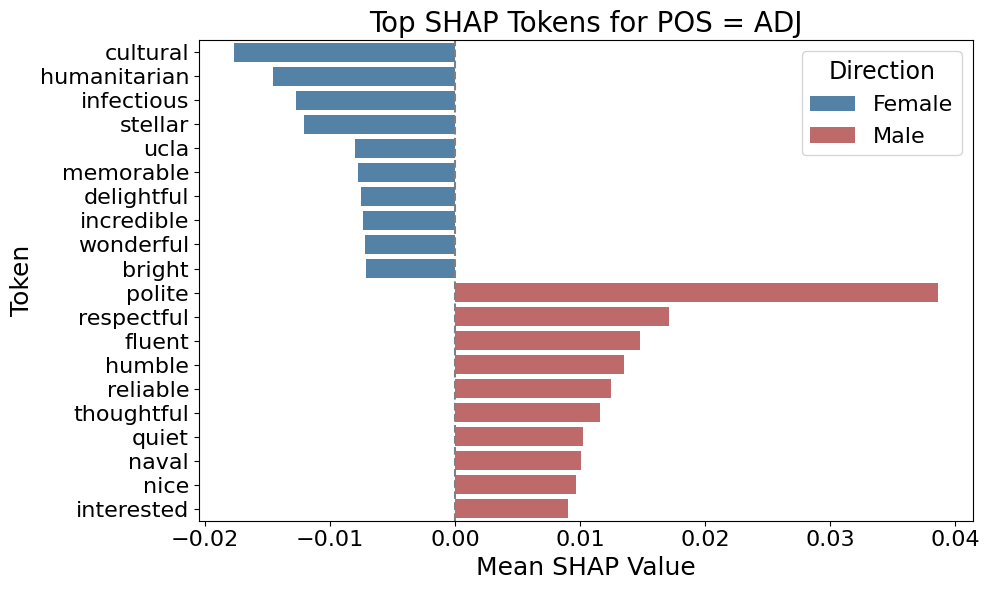

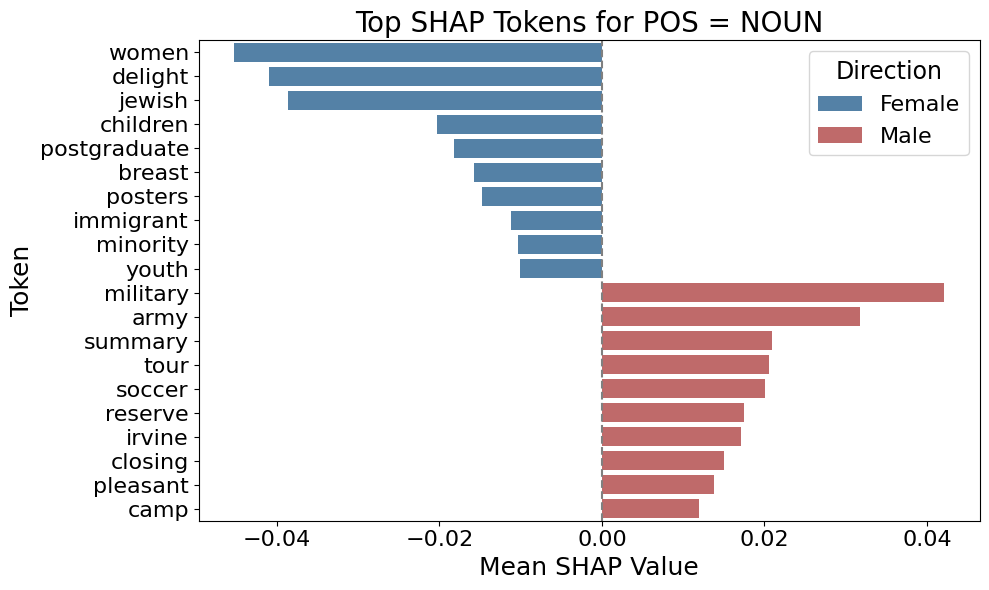

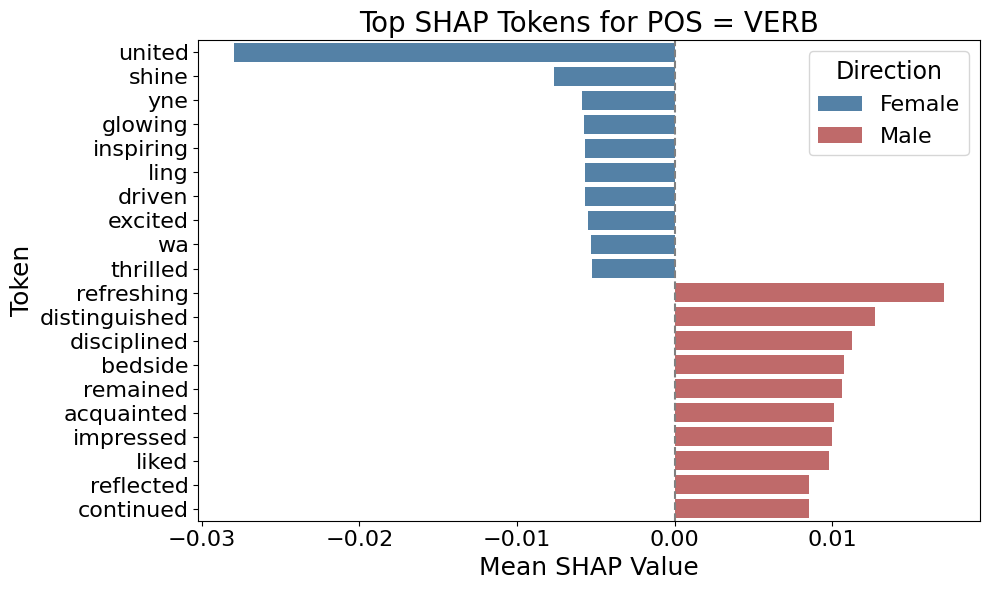

In [ ]:
adj_male, adj_female = plot_top_shap_by_pos(df_filtered, "ADJ", top_n=10, save_path=f'../figures/distillbert_adj_shap_chart_{split_num}.png')
noun_male, noun_female = plot_top_shap_by_pos(df_filtered, "NOUN", top_n=10, save_path=f'../figures/distillbert_noun_shap_chart_{split_num}.png')
verb_male, verb_female = plot_top_shap_by_pos(df_filtered, "VERB", top_n=10, save_path=f'../figures/distillbert_verb_shap_chart_{split_num}.png')


# Create Dataset With Implicit Gendered Tokens Removed

In [ ]:
train_orig = train_text.copy()
val_orig   = val_text.copy()
test_orig  = test_text.copy()

In [ ]:
train_shap = train_orig.copy()
val_shap   = val_orig.copy()
test_shap  = test_orig.copy()

In [ ]:
train_tfidf = train_orig.copy()
val_tfidf   = val_orig.copy()
test_tfidf  = test_orig.copy()

## SHAP

In [ ]:
import pandas as pd
from transformers import AutoTokenizer
import re

tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-uncased")
mask_token = tokenizer.mask_token  # '<mask>'

# Token list
token_list = all_tokens.tolist()

# Escape special regex characters
escaped_tokens = [re.escape(token) for token in token_list]
pattern = "(" + "|".join(escaped_tokens) + ")"

# Replace matches with spaced mask token
def mask_text(text):
    return re.sub(pattern, f" {mask_token} ", text)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
train_shap["full_text"] = train_shap["full_text"].apply(mask_text)
train_shap.to_csv(f"../data/train_test_val_splits/distillbert/implicit_gendered_tokens_removed_shap/train_text_{split_num}.csv", index=False)

In [ ]:
val_shap["full_text"] = val_shap["full_text"].apply(mask_text)
val_shap.to_csv(f"../data/train_test_val_splits/distillbert/implicit_gendered_tokens_removed_shap/val_text_{split_num}.csv", index=False)

In [ ]:
test_shap["full_text"] = test_shap["full_text"].apply(mask_text)
test_shap.to_csv(f"../data/train_test_val_splits/distillbert/implicit_gendered_tokens_removed_shap/test_text_{split_num}.csv", index=False)

## TFIDF

In [ ]:
all_tokens_df = pd.read_csv('../data/top_tokens_tfidf.csv')
all_tokens = all_tokens_df['token']

In [ ]:
import pandas as pd
from transformers import AutoTokenizer
import re

tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-uncased")
mask_token = tokenizer.mask_token  # '<mask>'

# Token list
token_list = all_tokens.tolist()

# Escape special regex characters
escaped_tokens = [re.escape(token) for token in token_list]
pattern = re.compile(
    r"\b(" + "|".join(escaped_tokens) + r")\b",
    flags=re.IGNORECASE
)

# Replace matches with spaced mask token
def mask_text(text):
    return re.sub(pattern, f" {mask_token} ", text)


In [ ]:
train_tfidf["full_text"] = train_tfidf["full_text"].apply(mask_text)
train_tfidf.to_csv(f"../data/train_test_val_splits/distillbert/implicit_gendered_tokens_removed_tfidf/train_text_{split_num}.csv", index=False)

In [ ]:
val_tfidf["full_text"] = val_tfidf["full_text"].apply(mask_text)
val_tfidf.to_csv(f"../data/train_test_val_splits/distillbert/implicit_gendered_tokens_removed_tfidf/val_text_{split_num}.csv", index=False)

In [ ]:
test_tfidf["full_text"] = test_tfidf["full_text"].apply(mask_text)
test_tfidf.to_csv(f"../data/train_test_val_splits/distillbert/implicit_gendered_tokens_removed_tfidf/test_text_{split_num}.csv", index=False)